# **Package Installations and Calls**

In [5]:
!pip install git+https://github.com/MaximeJumelle/ALEPython.git@dev#egg=alepython

  Cloning https://github.com/MaximeJumelle/ALEPython.git (to revision dev) to /tmp/pip-install-f76dyino/alepython_aa264ec97d254b4d9e2395e3d5a3a23b
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-f76dyino/alepython_aa264ec97d254b4d9e2395e3d5a3a23b
  Resolved https://github.com/MaximeJumelle/ALEPython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.0 MB/s eta 0:00:00
  Created wheel for alepython: filename=alepython-0.1.dev17+g286350a-py3-none-any.whl size=15167 sha256=ab83c6de38150896862a4ab4d0eb0bdc980006f494218d8c75fbbff6725e83e6
  Stored in directory: /tmp/pip-ephem-wheel-cache-5bqprgmh/wheels/ac/d2/e4/cd88ce55641d5422cdba165bd6f18c6fb6c0035385dc2bcce2
Successfully built alepython


In [6]:
!pip install PyALE

In [7]:
# Import DS Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Modeling libraries
import xgboost as xgb
from sklearn import metrics
from sklearn.model_selection import train_test_split, PredefinedSplit
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Extra tools
from tqdm import trange
from time import time
import pickle

# ALE plotting
from alepython import ale_plot
from PyALE import ale

In [9]:
from google.colab import drive
drive.mount('/drive')
%cd "/drive/MyDrive/Heart Research"

Mounted at /drive
/drive/MyDrive/Heart Research


# **Read in Data**

In [10]:
train_df = pd.read_csv("./data/trt_train.csv",
                       dtype = {"siteid" : "category", "sex" : "category",
                               "race" : "category", "historysmoking": "category"})
test_df = pd.read_csv("./data/trt_test.csv",
                      dtype = {"siteid" : "category", "sex" : "category",
                               "race" : "category", "historysmoking": "category"})

In [11]:
y_train = train_df["treatment_group"]
X_train = train_df.drop(["treatment_group", "randomized_study_binary"], axis = 1)
X_holdout = test_df.drop(["treatment_group", "randomized_study_binary"], axis = 1)
y_holdout = test_df["treatment_group"]
X_train.shape, y_train.shape

((90, 36), (90,))

In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   age                                             90 non-null     int64   
 1   sex                                             90 non-null     category
 2   siteid                                          90 non-null     category
 3   race                                            90 non-null     category
 4   ethnicity                                       90 non-null     int64   
 5   diabetes                                        90 non-null     int64   
 6   atrialfibflutter                                90 non-null     int64   
 7   CABG                                            90 non-null     int64   
 8   coronaryarterydisease                           90 non-null     int64   
 9   chronickidneydisease              

# **Set Up Data**

In [13]:
X = pd.concat([X_train, X_holdout])
y = pd.concat([y_train, y_holdout])

X['siteid'] = X['siteid'].astype('category')

# X.shape, y.shape

In [14]:
# X.info()

In [15]:
type(X)

pandas.core.frame.DataFrame

# **Make XGBoost Model**

## Find the Best Hyperparameters with Faux CV

We use singular cross-validation to find the best hyperparameters for the XGBoost dropout model fitted with the full dataset.

In [ ]:
start = time()

scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

# Make fake CV that just evaluates on training data
split_index = np.zeros(len(y), dtype = int)
ps = PredefinedSplit(test_fold = split_index)

xgb_model = xgb.XGBClassifier(random_state = 22,
                              scale_pos_weight = scale_pos_weight,
                              learning_rate = 0.05,
                              early_stopping_rounds = 15,
                              device = "cuda",
                              tree_method = "gpu_hist",
                              eval_metric = "auc",
                              enable_categorical = True,
                              verbosity = 0)

param_grid = {
    'n_estimators': [100, 300, 500, 700, 900, 1100], # Number of boosting trees
    'colsample_bytree': [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85],
    'max_depth': [5, 7, 9, 11, 13],               # Maximum depth of each tree
    'subsample': [0.4, 0.5, 0.6, 0.7, 0.8],    # Proportion of samples to train each tree
    'min_child_weight': [1, 3, 5]            # Minimum sum of instance weight for a child
}

# Grid search on training data only
grid_model = GridSearchCV(estimator = xgb_model, param_grid = param_grid,
                     cv = ps, n_jobs = -1, verbose = 2, scoring = 'f1')

grid_model.fit(X, y,
               eval_set = [(X, y)],
               verbose = False)

end = time()
print("Took", round(((end- start) / 60), 4), "minutes to search for the best model.")

Fitting 1 folds for each of 3150 candidates, totalling 3150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(


Took 3.1669 minutes to search for the best model.


In [ ]:
grid_model.best_params_

{'colsample_bytree': 0.5,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 100,
 'subsample': 0.4}

In [ ]:
print("Best training AUC:", grid_model.best_score_)

Best training AUC: nan


## Fit the Best Model

In [ ]:
params = grid_model.best_params_

scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

best_xgb_model = xgb.XGBClassifier(**params,
                                   random_state = 22,
                                   scale_pos_weight = scale_pos_weight,
                                   learning_rate = 0.05,
                                   early_stopping_rounds = 15,
                                   device = "cuda",
                                   tree_method = "gpu_hist",
                                   eval_metric = "auc",
                                   enable_categorical = True,
                                   verbosity = 0).fit(X, y,
                                                      eval_set = [(X, y)],
                                                      verbose = False)

In [ ]:
# Saving data by pickling data into pkl files to avoid running code for data again
# modeling = {
#     "cv_results": grid_model,
#     "best_model": best_xgb_model
# }
with open('explanatory_treatment_cv.pkl', 'wb') as file:
    pickle.dump(grid_model, file)
with open('explanatory_treatment_model.pkl', 'wb') as file:
    pickle.dump(best_xgb_model, file)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:11:26] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


# **Results**

## Get Predictions

In [16]:
# Read the pickled model and CV results
with open('explanatory_treatment_cv.pkl', 'rb') as file:
    grid_model = pickle.load(file)

with open('explanatory_treatment_model.pkl', 'rb') as file:
    xgb_model = pickle.load(file)

In [17]:
# Predicted labels and probabilities
y_pred_xgb = xgb_model.predict(X)
prob_pred_xgb = xgb_model.predict_proba(X)

In [18]:
# Probability Distribution
pd.DataFrame(prob_pred_xgb).describe()

,0,1
count,135.000000,135.000000
mean,0.590609,0.409391
std,0.249646,0.249646
min,0.102927,0.080629
25%,0.348702,0.201917
50%,0.699655,0.300345
75%,0.798083,0.651298
max,0.919371,0.897073


(array([19., 32., 22.,  7.,  4.,  6., 11., 13., 12.,  9.]),
 array([0.08062888, 0.16227326, 0.24391761, 0.325562  , 0.40720636,
        0.48885071, 0.57049513, 0.65213948, 0.73378384, 0.8154282 ,
        0.89707255]),
 <BarContainer object of 10 artists>)

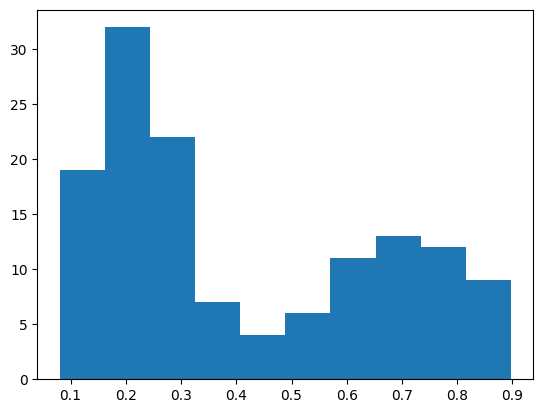

In [19]:
pos_probs = [i[1] for i in prob_pred_xgb]
plt.hist(pos_probs)

Text(0.5, 1.0, 'Distribution of Predicted Probs by True Label in the Treatment Model')

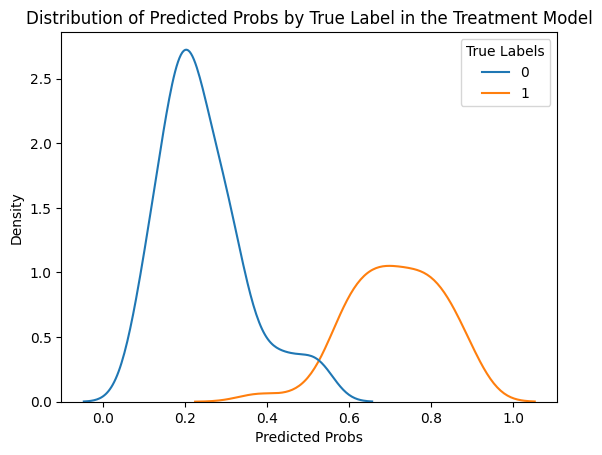

In [20]:
tmp = pd.concat([pd.DataFrame(pos_probs), y.reset_index(drop = True)],
                axis = 1)
tmp.columns = ["Predicted Probs", "True Labels"]
sns.kdeplot(data = tmp, x = "Predicted Probs", hue = "True Labels")#, kde = True)
plt.title("Distribution of Predicted Probs by True Label in the Treatment Model")

## View the CV Training Progress

In [21]:
# grid_model CV results
pd.DataFrame(grid_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_max_depth,param_min_child_weight,param_n_estimators,param_subsample,params,split0_test_score,mean_test_score,std_test_score,rank_test_score
0,1.039120,0.0,0.007944,0.0,0.50,5,1,100,0.4,"{'colsample_bytree': 0.5, 'max_depth': 5, 'min...",NaN,NaN,NaN,1
1,1.120457,0.0,0.002153,0.0,0.50,5,1,100,0.5,"{'colsample_bytree': 0.5, 'max_depth': 5, 'min...",NaN,NaN,NaN,1
2,0.183674,0.0,0.001005,0.0,0.50,5,1,100,0.6,"{'colsample_bytree': 0.5, 'max_depth': 5, 'min...",NaN,NaN,NaN,1
3,0.160661,0.0,0.001045,0.0,0.50,5,1,100,0.7,"{'colsample_bytree': 0.5, 'max_depth': 5, 'min...",NaN,NaN,NaN,1
4,0.075335,0.0,0.000925,0.0,0.50,5,1,100,0.8,"{'colsample_bytree': 0.5, 'max_depth': 5, 'min...",NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,0.103390,0.0,0.005683,0.0,0.85,13,5,1100,0.4,"{'colsample_bytree': 0.85, 'max_depth': 13, 'm...",NaN,NaN,NaN,1
3146,0.101126,0.0,0.004037,0.0,0.85,13,5,1100,0.5,"{'colsample_bytree': 0.85, 'max_depth': 13, 'm...",NaN,NaN,NaN,1
3147,0.074072,0.0,0.000955,0.0,0.85,13,5,1100,0.6,"{'colsample_bytree': 0.85, 'max_depth': 13, 'm...",NaN,NaN,NaN,1
3148,0.085207,0.0,0.000686,0.0,0.85,13,5,1100,0.7,"{'colsample_bytree': 0.85, 'max_depth': 13, 'm...",NaN,NaN,NaN,1


In [22]:
# Get evaluation results
results = xgb_model.evals_result()

# Extract train and validation loss
train_loss = results['validation_0']['auc']

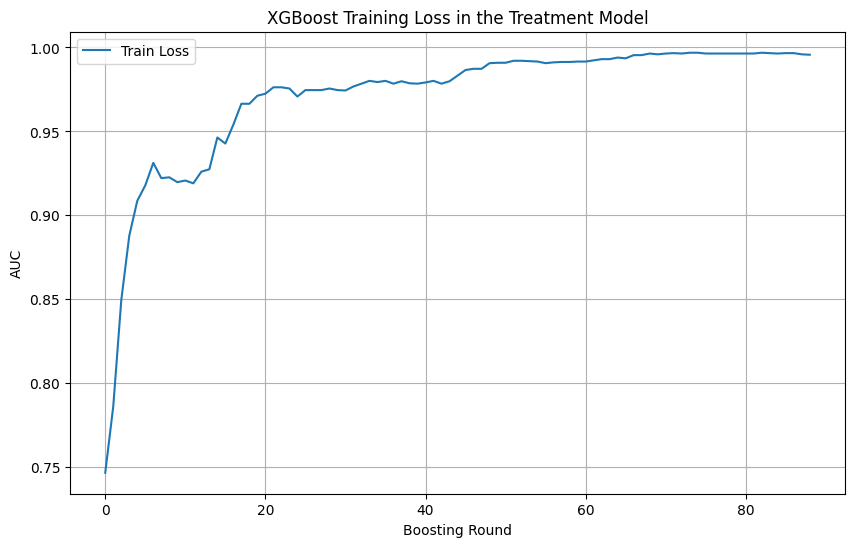

In [23]:
# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label = 'Train Loss')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Training Loss in the Treatment Model')
plt.legend()
plt.grid(True)
plt.show()

## Get Classification Metrics

In [24]:
def evaluate_metrics(y_vec, y_hat, prob_hat, model_name = "model"):
    # Confusion Matrix
    confMat = metrics.confusion_matrix(y_vec, y_hat)
    tn, fp, fn, tp = confMat.ravel()

    # Metrics
    accuracy = metrics.accuracy_score(y_vec, y_hat)
    sensitivity = metrics.recall_score(y_vec, y_hat)  # Same as recall (TPR)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 # No inf division
    precision = metrics.precision_score(y_vec, y_hat)
    recall = sensitivity
    f1 = metrics.f1_score(y_vec, y_hat)
    brier = metrics.brier_score_loss(y_vec, prob_hat)
    auc = metrics.roc_auc_score(y_vec, prob_hat)

    # Store all metrics in a dictionary
    all_metrics = {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "brier": brier,
        "auc": auc
    }

    # dataframe to column bind to others for viewing
    return pd.DataFrame(all_metrics, index=[model_name]).T

In [25]:
# Get all composite classification metrics
xgb_train_metrics = evaluate_metrics(y, y_pred_xgb,
                                    pos_probs, # probabilities of being in class 1
                                    model_name = "XGB Train")

In [26]:
xgb_train_metrics

,XGB Train
accuracy,0.955556
sensitivity,0.958333
specificity,0.954023
precision,0.920000
recall,0.958333
f1,0.938776
tp,46.000000
fp,4.000000
tn,83.000000
fn,2.000000


## AUC Plot

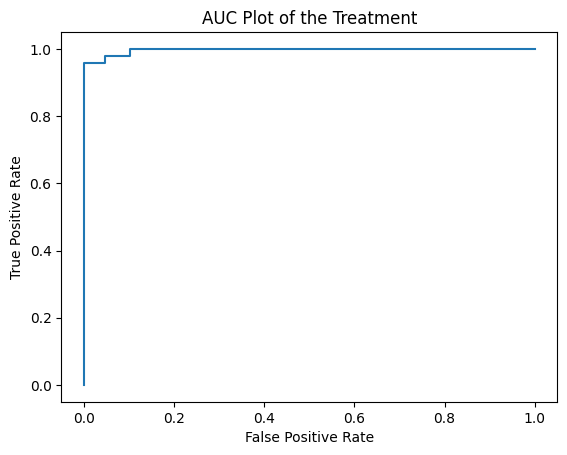

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("AUC Plot of the Treatment")

plot_roc_curve(y, pos_probs)

## Feature Importance

<Axes: title={'center': 'XGBoost Treatment Model Feature Importance'}, xlabel='F score', ylabel='Features'>

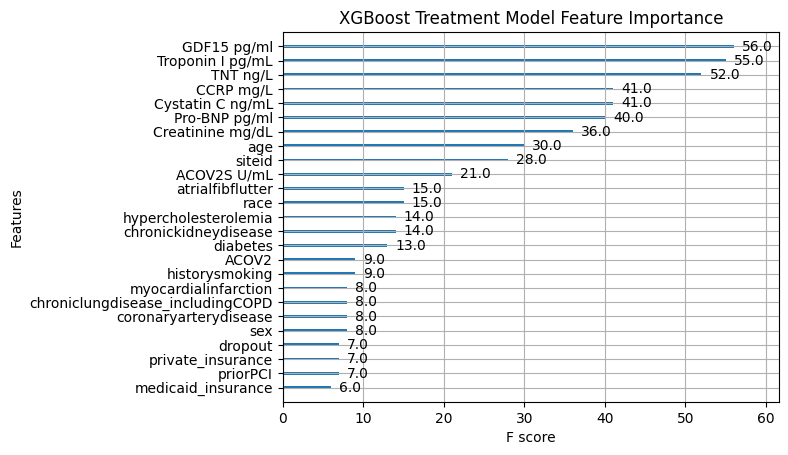

In [28]:
xgb_model.get_booster().feature_names = X.columns.to_list()
xgb.plot_importance(xgb_model, max_num_features = 25, title = "XGBoost Treatment Model Feature Importance")

In [32]:
# # Get feature importance scores
# importance = xgb_model.feature_importances_

# # Create a DataFrame to display feature importance
# feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
# feature_importance = feature_importance.sort_values('Importance', ascending=False)

# # Print the top N important features (e.g., top 10)
# top_n = 10
# print(f"Top {top_n} Important Features:")
# print(feature_importance.head(top_n))

pd.DataFrame({'col_name': xgb_model.feature_importances_}, index=X.columns).sort_values(by='col_name', ascending=False)

,col_name
sex,0.071584
hypercholesterolemia,0.045584
chronickidneydisease,0.043768
siteid,0.042727
Cystatin C ng/mL,0.041476
priorHF,0.041452
TNT ng/L,0.040997
Creatinine mg/dL,0.039220
Troponin I pg/mL,0.036374
ACOV2,0.036007


In [34]:
# Create a Series with feature importances
importance_df = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Get top 15 most important features
top15 = importance_df.sort_values(ascending=False).head(15)
print(top15)

NameError: name 'feature_names' is not defined

## ALE Plots

### Categorical Variables

In [ ]:
# Set up for all categorical variables
X_ale = X.copy()

# Convert categorical variables to numeric code (just for ALE) to get model values
X_ale["siteid"] = X_ale["siteid"].cat.codes
X_ale["sex"] = X_ale["sex"].cat.codes
X_ale["race"] = X_ale["race"].cat.codes
X_ale["historysmoking"] = X_ale["historysmoking"].cat.codes

#### siteid

Key for location and siteid:
* **UNC**: 101
* **Duke**: 104
* **Yale**: 122
* **Inova**: 129
* **Northwell**: 146
* **VA Medical Center**: 210
* **Ochsner**: 235
* **UMN**: 413
* **Sentara**: 417

In [ ]:
print("Number of patients in each site present in the dataset.")
X["siteid"].value_counts()

Number of patients in each site present in the dataset.


,count
siteid,
146,48
129,33
235,26
417,19
101,5
104,4


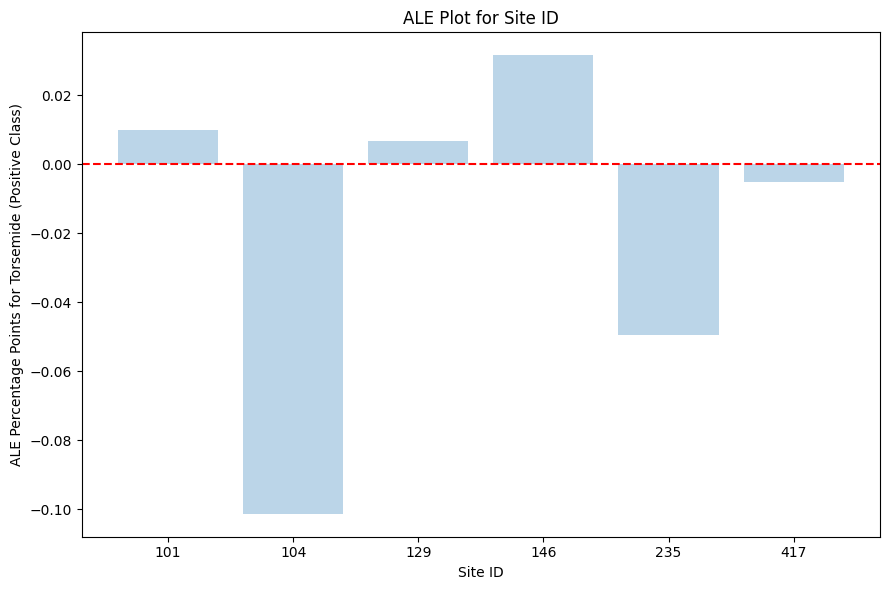

In [ ]:
ale_result = ale(
    X = X_ale,
    model = xgb_model,
    feature = ["siteid"],
    feature_type = "discrete",
    include_CI = False,
    plot = False
)

# Get original category
siteid_labels = dict(enumerate(X["siteid"].cat.categories))

# Replace index with original labels
ale_df = ale_result.copy()
ale_df.index = ale_df.index.map(siteid_labels)

# Plot
plt.figure(figsize = (9, 6))
#plt.plot(ale_df.index, ale_df["eff"])
plt.bar(ale_df.index, ale_df["eff"], alpha = 0.3)
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("Site ID")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("ALE Plot for Site ID")
plt.tight_layout()
plt.show()

#### sex

In [ ]:
print("Number of patients in each sex present in the dataset.")
X["sex"].value_counts()

Number of patients in each sex present in the dataset.


,count
sex,
Male,98
Female,37


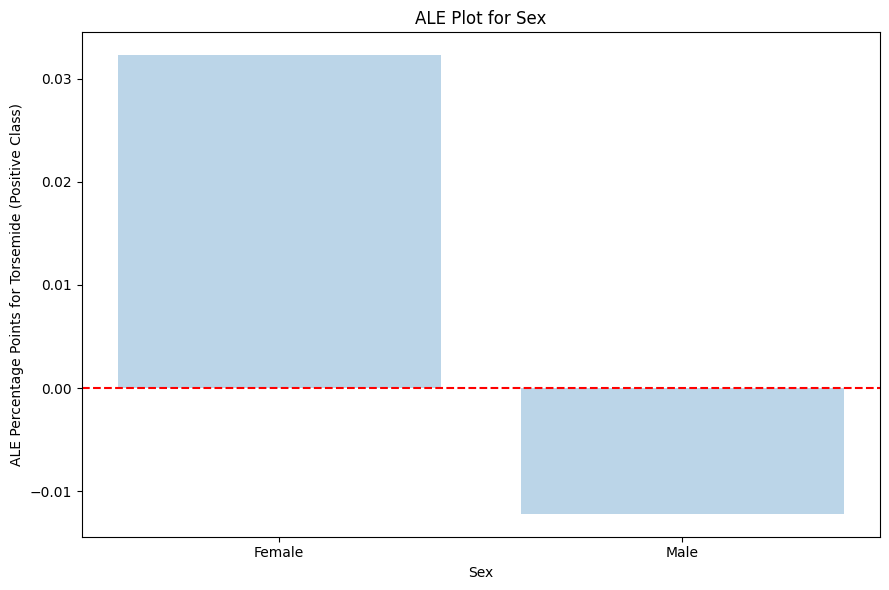

In [ ]:
ale_result = ale(
    X = X_ale,
    model = xgb_model,
    feature = ["sex"],
    feature_type = "discrete",
    include_CI = False,
    plot = False
)

# Get original category
siteid_labels = dict(enumerate(X["sex"].cat.categories))

# Replace index with original labels
ale_df = ale_result.copy()
ale_df.index = ale_df.index.map(siteid_labels)

# Plot
plt.figure(figsize = (9, 6))
#plt.plot(ale_df.index, ale_df["eff"])
plt.bar(ale_df.index, ale_df["eff"], alpha = 0.3)
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("Sex")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("ALE Plot for Sex")
plt.tight_layout()
plt.show()

#### race

In [ ]:
print("Number of patients in each race present in the dataset.")
X["race"].value_counts()

Number of patients in each race present in the dataset.


,count
race,
Caucasian,68
Black,40
Other,22
Asian,5


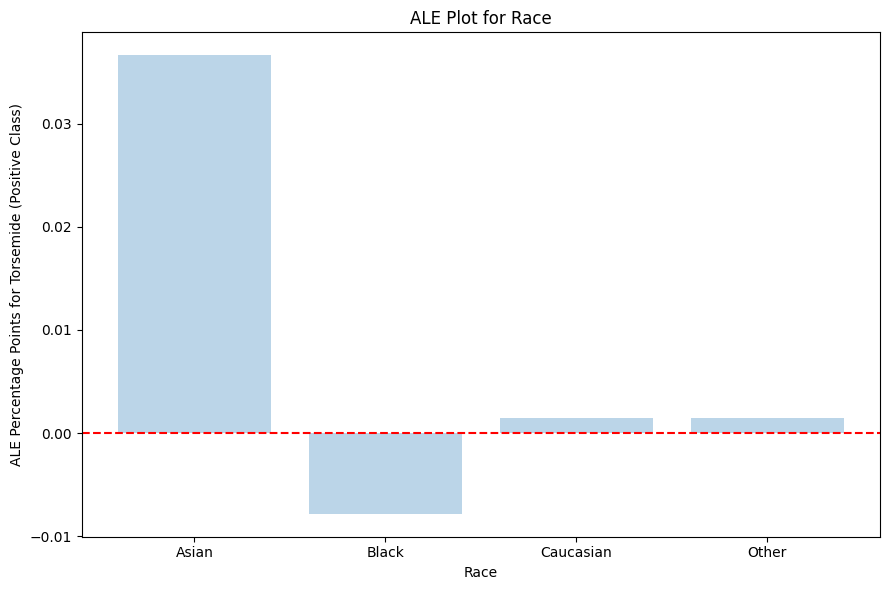

In [ ]:
ale_result = ale(
    X = X_ale,
    model = xgb_model,
    feature = ["race"],
    feature_type = "discrete",
    include_CI = False,
    plot = False
)

# Get original category
siteid_labels = dict(enumerate(X["race"].cat.categories))

# Replace index with original labels
ale_df = ale_result.copy()
ale_df.index = ale_df.index.map(siteid_labels)

# Plot
plt.figure(figsize = (9, 6))
#plt.plot(ale_df.index, ale_df["eff"])
plt.bar(ale_df.index, ale_df["eff"], alpha = 0.3)
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("Race")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("ALE Plot for Race")
plt.tight_layout()
plt.show()

#### historysmoking

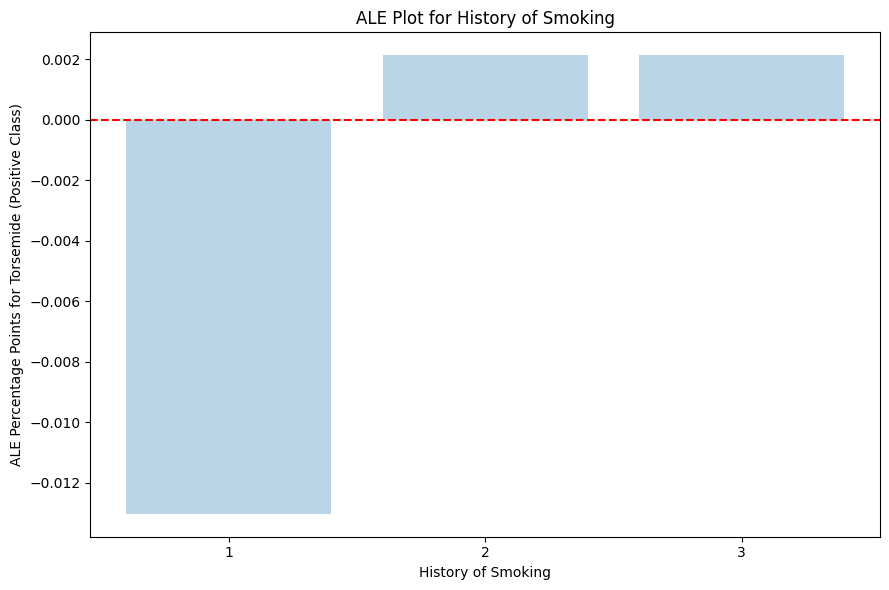

In [ ]:
ale_result = ale(
    X = X_ale,
    model = xgb_model,
    feature = ["historysmoking"],
    feature_type = "discrete",
    include_CI = False,
    plot = False
)

# Get original category
siteid_labels = dict(enumerate(X["historysmoking"].cat.categories))

# Replace index with original labels
ale_df = ale_result.copy()
ale_df.index = ale_df.index.map(siteid_labels)

# Plot
plt.figure(figsize = (9, 6))
#plt.plot(ale_df.index, ale_df["eff"])
plt.bar(ale_df.index, ale_df["eff"], alpha = 0.3)
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("History of Smoking")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("ALE Plot for History of Smoking")
plt.tight_layout()
plt.show()

In [ ]:
ale_df

,eff,size
historysmoking,,
1,-0.013019,19
2,0.002132,47
3,0.002132,69


### Numeric Variables

#### age

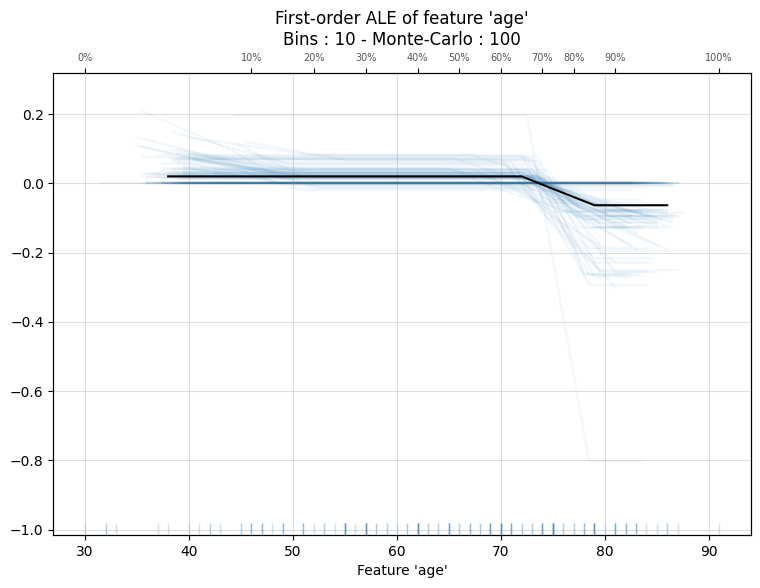

<Axes: title={'center': "First-order ALE of feature 'age'\nBins : 10 - Monte-Carlo : 100"}, xlabel="Feature 'age'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "age",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)

#### TNT ng/L

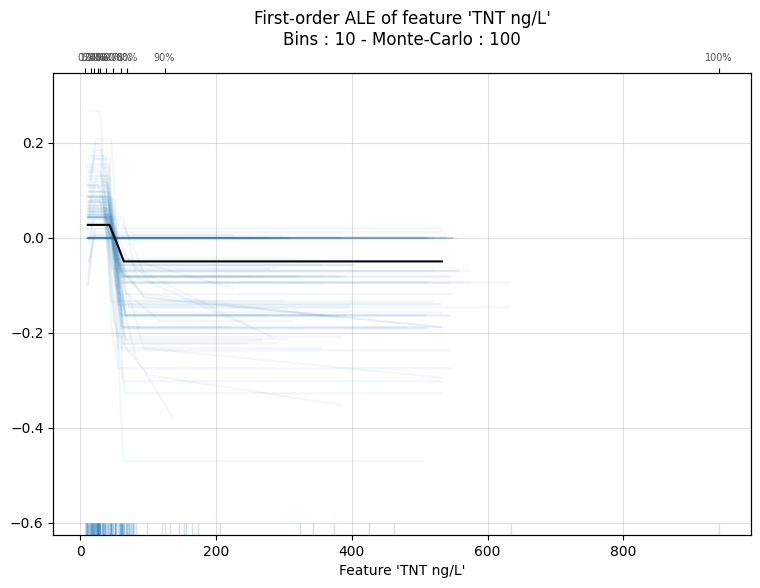

<Axes: title={'center': "First-order ALE of feature 'TNT ng/L'\nBins : 10 - Monte-Carlo : 100"}, xlabel="Feature 'TNT ng/L'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "TNT ng/L",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6
)

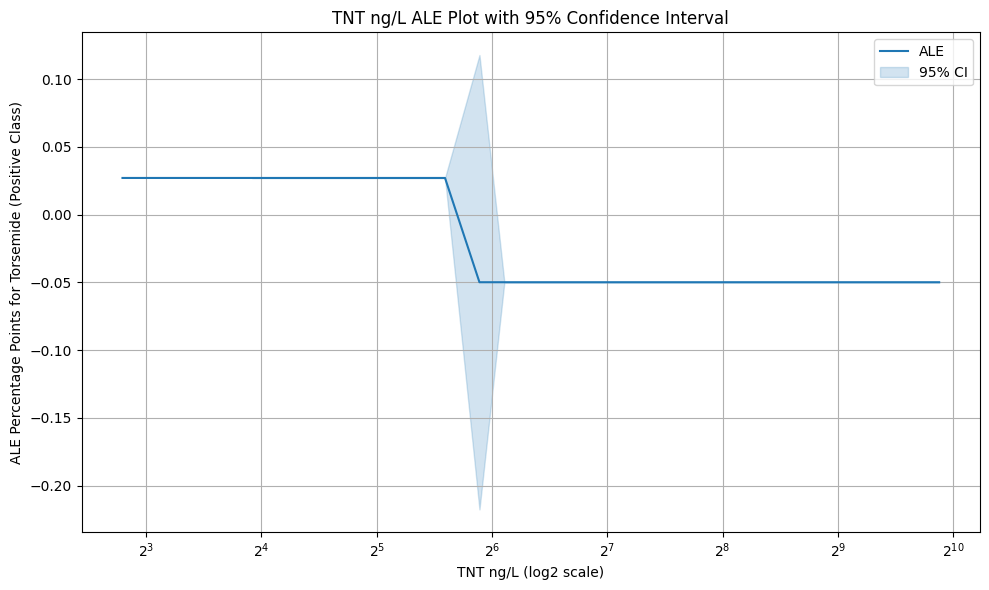

In [ ]:
# Compute ALE values directly (no plotting)
ale_eff = ale(
    X = X,
    model = xgb_model,
    feature = ["TNT ng/L"],
    feature_type = "continuous",
    grid_size = 10,
    include_CI = True,
    plot = False
)

tmp1 = pd.DataFrame(ale_eff)
tmp1.index.name = "biomarker_values"
tmp1.reset_index(inplace = True)
tmp1

# Plot
plt.figure(figsize = (10, 6))
plt.plot(tmp1["biomarker_values"], ale_eff["eff"],
         label = "ALE", color = "C0")
plt.fill_between(tmp1["biomarker_values"],
                 ale_eff["lowerCI_95%"], ale_eff["upperCI_95%"],
                 color = "C0", alpha = 0.2, label = "95% CI")
plt.xscale("log", base=2)

plt.xlabel("TNT ng/L (log2 scale)")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("TNT ng/L ALE Plot with 95% Confidence Interval")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### CCRP mg/L

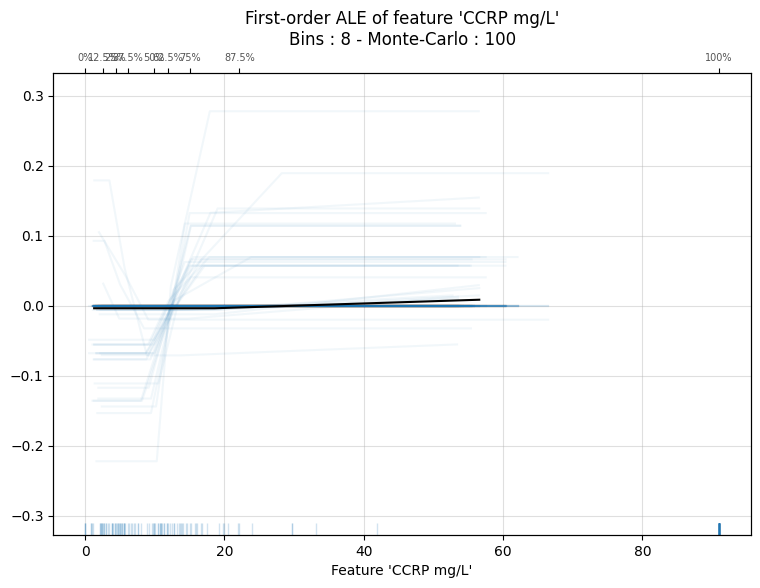

<Axes: title={'center': "First-order ALE of feature 'CCRP mg/L'\nBins : 8 - Monte-Carlo : 100"}, xlabel="Feature 'CCRP mg/L'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "CCRP mg/L",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)

#### Troponin I pg/mL

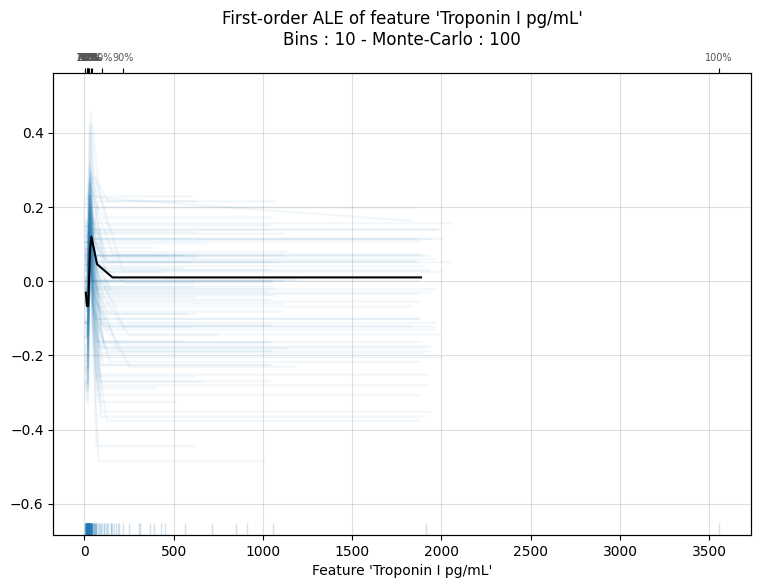

<Axes: title={'center': "First-order ALE of feature 'Troponin I pg/mL'\nBins : 10 - Monte-Carlo : 100"}, xlabel="Feature 'Troponin I pg/mL'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "Troponin I pg/mL",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6
)

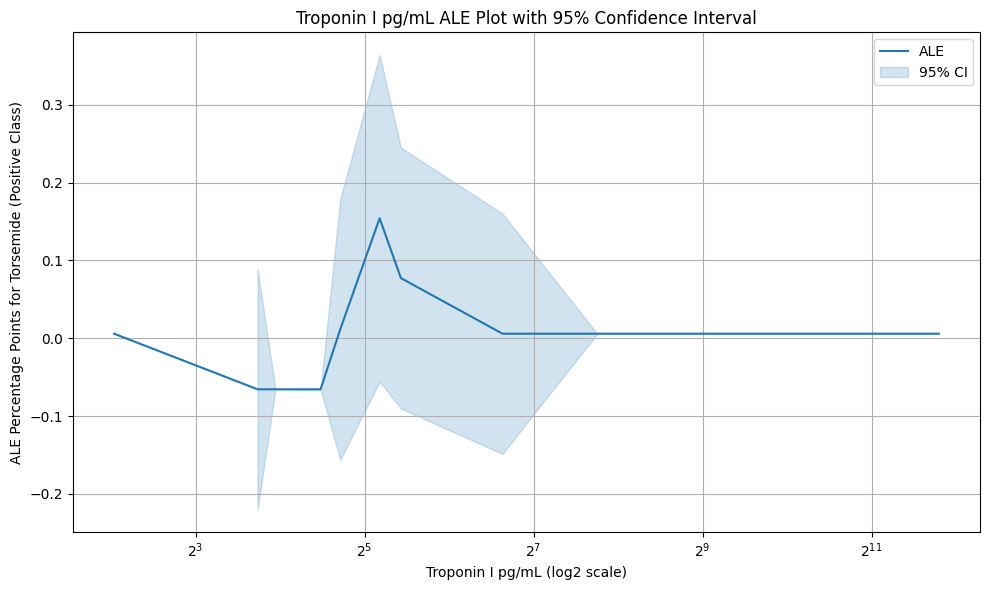

In [ ]:
# Compute ALE values directly (no plotting)
ale_eff = ale(
    X = X,
    model = xgb_model,
    feature = ["Troponin I pg/mL"],
    feature_type = "continuous",
    grid_size = 10,
    include_CI = True,
    plot = False
)

tmp1 = pd.DataFrame(ale_eff)
tmp1.index.name = "biomarker_values"
tmp1.reset_index(inplace = True)
tmp1

# Plot
plt.figure(figsize = (10, 6))
plt.plot(tmp1["biomarker_values"], ale_eff["eff"],
         label = "ALE", color = "C0")
plt.fill_between(tmp1["biomarker_values"],
                 ale_eff["lowerCI_95%"], ale_eff["upperCI_95%"],
                 color = "C0", alpha = 0.2, label = "95% CI")
plt.xscale("log", base=2)

plt.xlabel("Troponin I pg/mL (log2 scale)")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("Troponin I pg/mL ALE Plot with 95% Confidence Interval")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Creatinine mg/dL

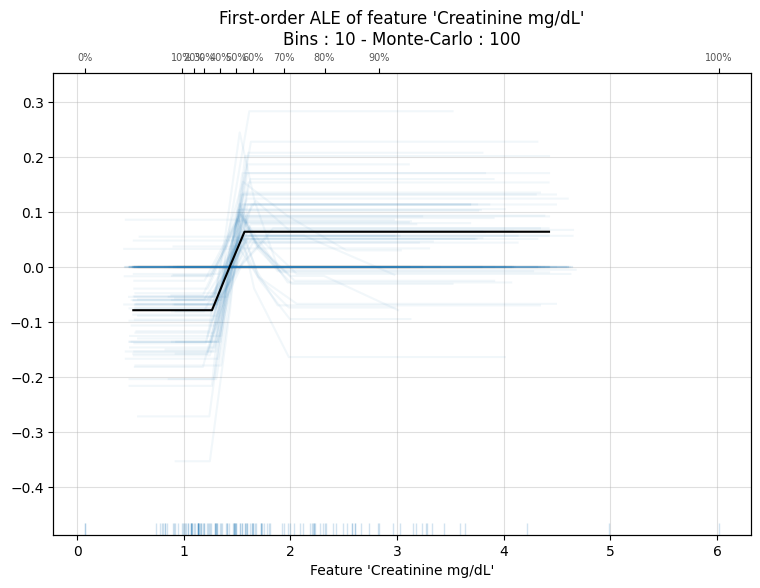

<Axes: title={'center': "First-order ALE of feature 'Creatinine mg/dL'\nBins : 10 - Monte-Carlo : 100"}, xlabel="Feature 'Creatinine mg/dL'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "Creatinine mg/dL",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)

#### 2D of Creatinine and Cystatin C

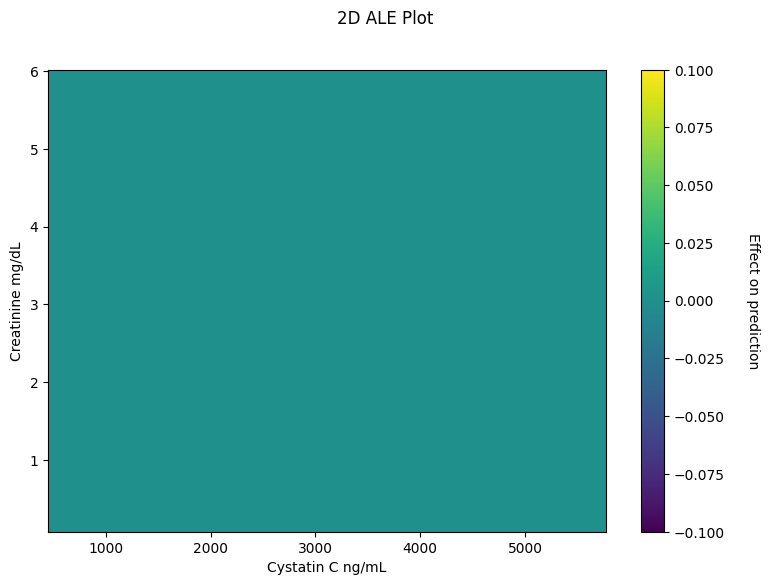

In [ ]:
## 2D - continuous
ale_eff = ale(X=X, model=xgb_model, feature=["Creatinine mg/dL", "Cystatin C ng/mL"], grid_size=36) # TODO grid_size

#### Cystatin C ng/mL

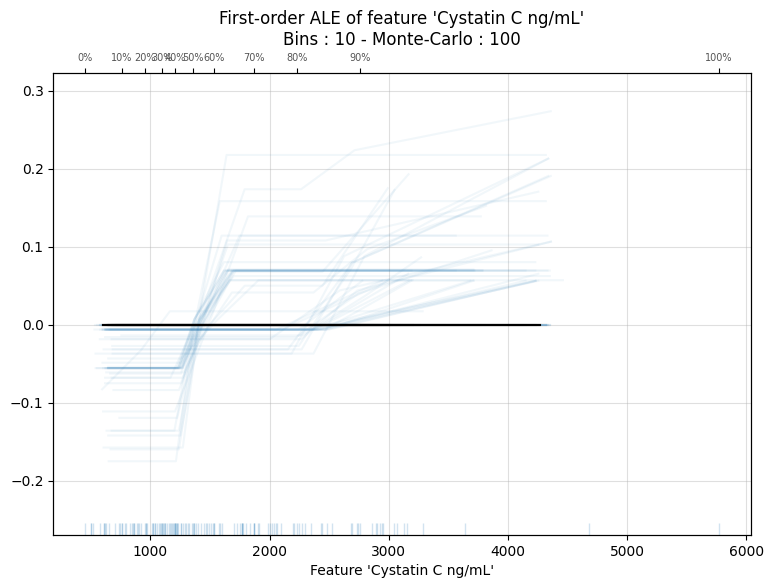

<Axes: title={'center': "First-order ALE of feature 'Cystatin C ng/mL'\nBins : 10 - Monte-Carlo : 100"}, xlabel="Feature 'Cystatin C ng/mL'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "Cystatin C ng/mL",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)

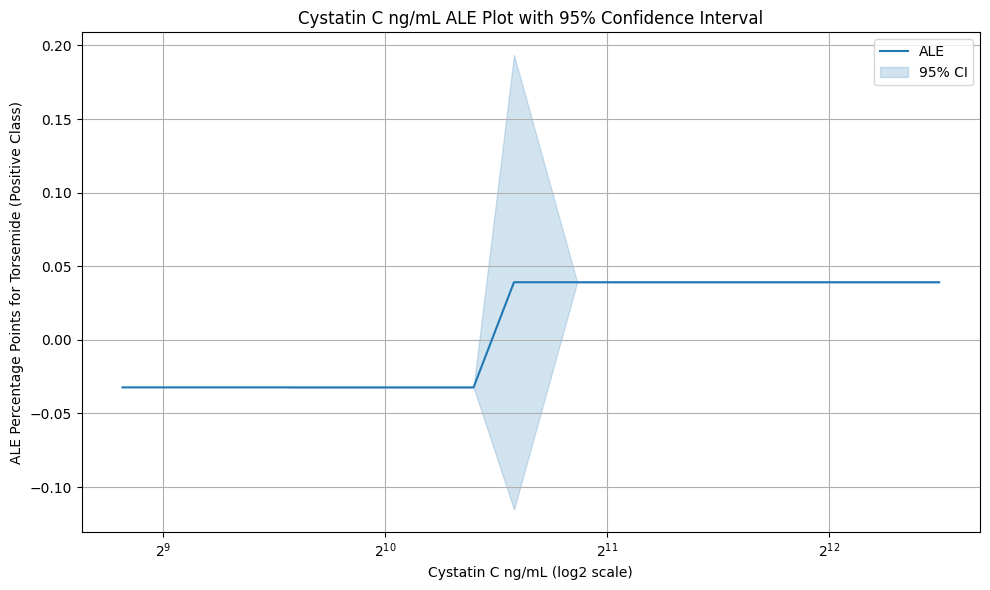

In [ ]:
# Compute ALE values directly (no plotting)
ale_eff = ale(
    X = X,
    model = xgb_model,
    feature = ["Cystatin C ng/mL"],
    feature_type = "continuous",
    grid_size = 10,
    include_CI = True,
    plot = False
)

tmp1 = pd.DataFrame(ale_eff)
tmp1.index.name = "biomarker_values"
tmp1.reset_index(inplace = True)
tmp1

# Plot
plt.figure(figsize = (10, 6))
plt.plot(tmp1["biomarker_values"], ale_eff["eff"],
         label = "ALE", color = "C0")
plt.fill_between(tmp1["biomarker_values"],
                 ale_eff["lowerCI_95%"], ale_eff["upperCI_95%"],
                 color = "C0", alpha = 0.2, label = "95% CI")
plt.xscale("log", base=2)

plt.xlabel("Cystatin C ng/mL (log2 scale)")
plt.ylabel("ALE Percentage Points for Torsemide (Positive Class)")
plt.title("Cystatin C ng/mL ALE Plot with 95% Confidence Interval")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### ACOV2S U/mL

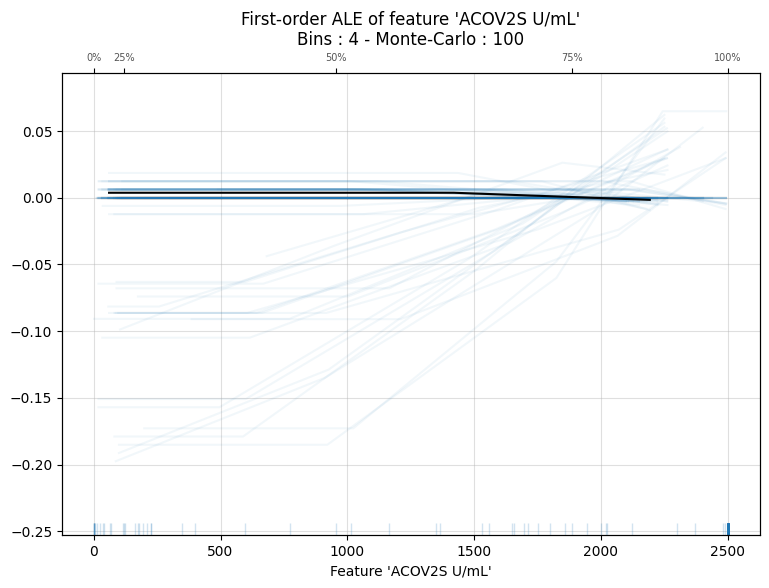

<Axes: title={'center': "First-order ALE of feature 'ACOV2S U/mL'\nBins : 4 - Monte-Carlo : 100"}, xlabel="Feature 'ACOV2S U/mL'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "ACOV2S U/mL",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)

In [ ]:
# ## 2D - continuous
# ale_eff = ale(X=X, model=best_xgb_model, feature=["ACOV2S U/mL", "CCRP mg/L"], grid_size=100)

#### GDF15 pg/ml

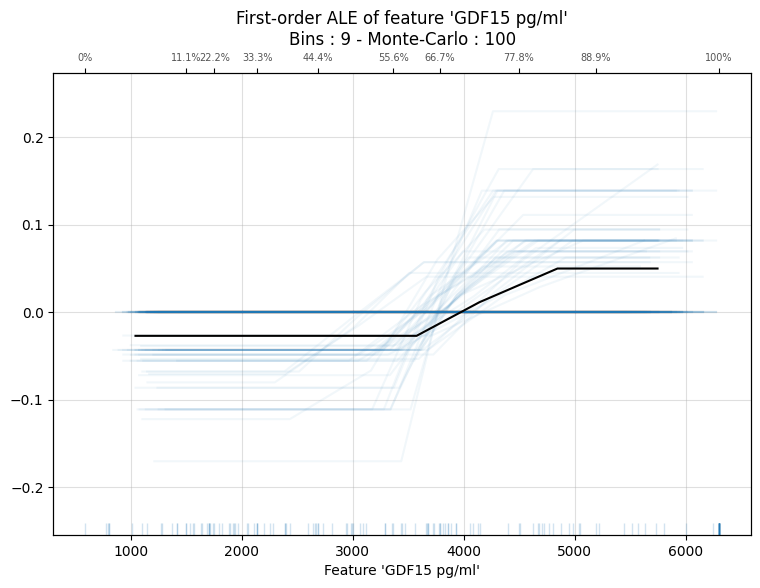

<Axes: title={'center': "First-order ALE of feature 'GDF15 pg/ml'\nBins : 9 - Monte-Carlo : 100"}, xlabel="Feature 'GDF15 pg/ml'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "GDF15 pg/ml",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)

#### Pro-BNP pg/ml

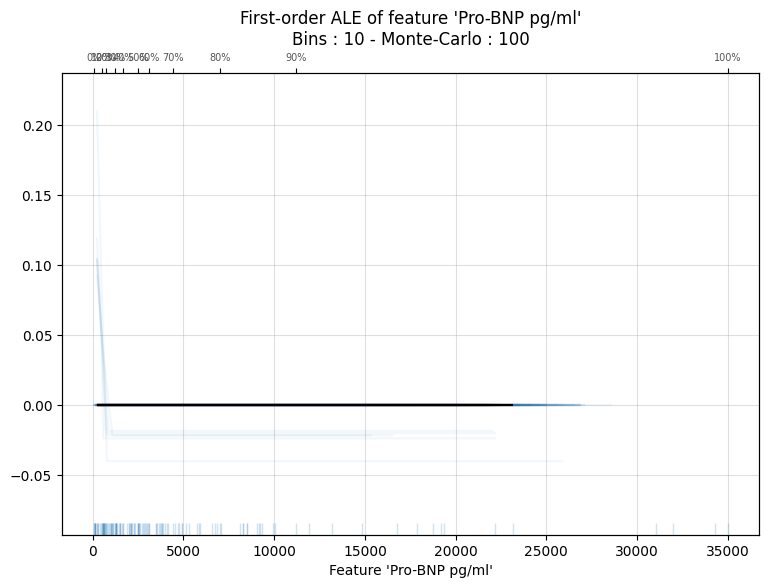

<Axes: title={'center': "First-order ALE of feature 'Pro-BNP pg/ml'\nBins : 10 - Monte-Carlo : 100"}, xlabel="Feature 'Pro-BNP pg/ml'">

In [ ]:
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
mpl.rc("figure", figsize=(9, 6))
ale_plot(
    xgb_model,
    X,
    "Pro-BNP pg/ml",
    bins = 10,
    monte_carlo = True,
    monte_carlo_rep = 100,
    monte_carlo_ratio = 0.6,
)